<a href="https://colab.research.google.com/github/celdeev/calculator-project/blob/main/Kopi_af_chapters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data sampling with a sliding window


In [134]:
import os
import urllib.request
import re

file_path = "the-verdict.txt"

if not os.path.exists(file_path):
    url = "https://raw.githubusercontent.com/celdeev/git-course/main/the-verdict.txt"
    urllib.request.urlretrieve(url, file_path)

with open(file_path, "r", encoding="utf-8") as f:
    raw_text = f.read()



In [135]:
import re
result= re.split(r'([,.?_!"()\']|--|\s)', raw_text)
result = [item.strip() for item in result if item.strip()]
print(result)
raw_text

['I', 'HAD', 'always', 'thought', 'Jack', 'Gisburn', 'rather', 'a', 'cheap', 'genius', '--', 'though', 'a', 'good', 'fellow', 'enough', '--', 'so', 'it', 'was', 'no', 'great', 'surprise', 'to', 'me', 'to', 'hear', 'that', ',', 'in', 'the', 'height', 'of', 'his', 'glory', ',', 'he', 'had', 'dropped', 'his', 'painting', ',', 'married', 'a', 'rich', 'widow', ',', 'and', 'established', 'himself', 'in', 'a', 'villa', 'on', 'the', 'Riviera', '.', '(', 'Though', 'I', 'rather', 'thought', 'it', 'would', 'have', 'been', 'Rome', 'or', 'Florence', '.', ')', '"', 'The', 'height', 'of', 'his', 'glory', '"', '--', 'that', 'was', 'what', 'the', 'women', 'called', 'it', '.', 'I', 'can', 'hear', 'Mrs', '.', 'Gideon', 'Thwing', '--', 'his', 'last', 'Chicago', 'sitter', '--', 'deploring', 'his', 'unaccountable', 'abdication', '.', '"', 'Of', 'course', 'it', "'", 's', 'going', 'to', 'send', 'the', 'value', 'of', 'my', 'picture', "'", 'way', 'up;', 'but', 'I', 'don', "'", 't', 'think', 'of', 'that', ',', '

'I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no great surprise to me to hear that, in the height of his glory, he had dropped his painting, married a rich widow, and established himself in a villa on the Riviera. (Though I rather thought it would have been Rome or Florence.)\n\n"The height of his glory"--that was what the women called it. I can hear Mrs. Gideon Thwing--his last Chicago sitter--deploring his unaccountable abdication. "Of course it\'s going to send the value of my picture \'way up; but I don\'t think of that, Mr. Rickham--the loss to Arrt is all I think of." The word, on Mrs. Thwing\'s lips, multiplied its _rs_ as though they were reflected in an endless vista of mirrors. And it was not only the Mrs. Thwings who mourned. Had not the exquisite Hermia Croft, at the last Grafton Gallery show, stopped me before Gisburn\'s "Moon-dancers" to say, with tears in her eyes: "We shall not look upon its like again"?\n\nWell!--even 

In [136]:
import re

class SimpleTokenizerV2:
    def __init__(self, vocab):
        self.str_to_int = vocab
        self.int_to_str = {i: s for s, i in vocab.items()}

    def encode(self, text):
        preprocessed = re.split(r'([,.?_!"()\']|--|\s)', text)
        preprocessed = [item.strip() for item in preprocessed if item.strip()]

        preprocessed = [
            item if item in self.str_to_int else "<|unk|>"
            for item in preprocessed
        ]

        ids = [self.str_to_int[token] for token in preprocessed]
        return ids

    def decode(self, ids):
        text = " ".join([self.int_to_str[i] for i in ids])
        text = re.sub(r'\s+([,.?!"()\'])', r'\1', text)
        return text

In [137]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

preprocessed = re.split(r'([,.?_!"()\']|--|\s)', raw_text)
preprocessed = [item.strip() for item in preprocessed if item.strip()]

all_tokens = sorted(set(preprocessed))
all_tokens.extend(["<|endoftext|>", "<|unk|>"])

vocab = {token: idx for idx, token in enumerate(all_tokens)}

In [138]:
tokenizer = SimpleTokenizerV2(vocab)

enc_text = tokenizer.encode(raw_text)
print(len(enc_text))



4649


In [139]:

enc_sample=enc_text[50:]

In [140]:
len(enc_sample)

4599

In [141]:
context_size = 4 #A
x = enc_sample[:context_size]
y = enc_sample[1:context_size+1]
print(f"x: {x}")
print(f"y: {y}")

x: [579, 119, 1093, 743]
y: [119, 1093, 743, 1013]


In [142]:
for i in range(1, context_size + 1):
    context = enc_sample[:i]
    desired = enc_sample[i]
    print(tokenizer.decode(context), "---->", tokenizer.decode([desired]))

in ----> a
in a ----> villa
in a villa ----> on
in a villa on ----> the


In [143]:
import torch

In [144]:
pip install torch

In [145]:
torch.__version__

'2.11.0+cpu'

In [146]:
import torch
from torch.utils.data import Dataset, DataLoader

class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.tokenizer = tokenizer
        self.input_ids = []
        self.target_ids = []

        token_ids = tokenizer.encode(txt) #A

        for i in range(0, len(token_ids) - max_length, stride): #B
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self): #C
        return len(self.input_ids)

    def __getitem__(self, idx): #D
        return self.input_ids[idx], self.target_ids[idx]

In [147]:
# ex 1
# ex 2

# ex 3
# ex 4

# ex 5
# ex 6


In [148]:
def create_dataloader_v1(txt, batch_size=4,
        max_length=256, stride=128, shuffle=True, drop_last=True):
    tokenizer = tiktoken.get_encoding("gpt2") #A
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride) #B
    dataloader = DataLoader(
        dataset, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last)
    return dataloader

In [149]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

In [150]:
!pip install tiktoken

In [151]:
import tiktoken
dataloader = create_dataloader_v1(
raw_text, batch_size=1, max_length=4, stride=4, shuffle=False)
data_iter = iter(dataloader) #A
first_batch = next(data_iter)
print(first_batch)

[tensor([[  40,  367, 2885, 1464]]), tensor([[ 367, 2885, 1464, 1807]])]


In [152]:
second_batch = next(data_iter)
print(second_batch)

[tensor([[1807, 3619,  402,  271]]), tensor([[ 3619,   402,   271, 10899]])]


In [153]:
dataloader = create_dataloader_v1(raw_text, batch_size=8, max_length=4, stride=4)
data_iter = iter(dataloader)
inputs, targets = next(data_iter)
print("Inputs:\n", inputs)
print("\nTargets:\n", targets)

Inputs:
 tensor([[ 3465,   326, 26773,   606],
        [ 6846,   338, 11428,   450],
        [ 1110,   526,   198,   198],
        [  464,  1109,  3181,  1363],
        [  536,  5469,   550, 11001],
        [12225,   783,   290,   788],
        [  290, 44852,    88,    13],
        [  326,   526,   198,   198]])

Targets:
 tensor([[  326, 26773,   606,   286],
        [  338, 11428,   450,    67],
        [  526,   198,   198,  1870],
        [ 1109,  3181,  1363,   284],
        [ 5469,   550, 11001,    11],
        [  783,   290,   788, 11061],
        [44852,    88,    13,  2735],
        [  526,   198,   198,  5779]])


In [154]:
input_ids = torch.tensor([2, 3, 5, 1])

In [155]:
all_words=(set(preprocessed))
vocab_size=len(all_words)
print(vocab_size)

1159


In [156]:
import torch
output_dim=256
torch.manual_seed(123)
embedding_layer = torch.nn.Embedding(vocab_size, output_dim)
print(embedding_layer.weight)

Parameter containing:
tensor([[ 0.3374, -0.1778, -0.3035,  ...,  1.3337,  0.0771, -0.0522],
        [ 0.2386,  0.1411, -1.3354,  ..., -0.0315, -1.0640,  0.9417],
        [-1.3152, -0.0677, -0.1350,  ..., -0.3181, -1.3936,  0.5226],
        ...,
        [-0.6676,  0.4930,  1.8076,  ..., -0.2217, -1.7445,  0.6017],
        [ 0.8160,  0.0374,  0.8645,  ..., -2.3497, -0.3007,  0.0668],
        [ 0.5285,  0.1770,  1.7616,  ..., -1.5837,  0.9336,  0.6181]],
       requires_grad=True)


In [157]:
print(embedding_layer(torch.tensor([2])))

tensor([[-1.3152, -0.0677, -0.1350, -0.5183,  0.2326,  1.6311, -0.8707,  0.0490,
         -0.2526,  0.0810,  1.2702,  0.7397,  1.0890, -0.6591, -0.1910,  0.5061,
          1.7788, -0.7092, -1.5262, -1.4693,  3.2052, -0.2765, -0.0540,  0.6673,
         -0.5023, -1.1043,  0.8741, -1.4747, -0.0785, -0.9214, -1.2015, -0.1640,
          1.1366, -0.7330,  1.3382,  0.2706,  0.5071,  0.0171, -0.3081, -1.1696,
         -0.4264, -0.9266,  0.4074, -0.0637, -1.4105, -1.1709, -1.0945, -0.3700,
         -0.0037,  0.6299,  0.5173,  0.6031, -1.0045,  0.1959,  1.4460, -2.4599,
         -0.7120, -1.7431,  0.0511, -0.2768, -0.6183,  0.4465,  2.0123, -2.3251,
          1.2701, -0.5276,  0.9680,  0.6084,  0.2185, -1.9706, -0.6639, -0.0259,
          1.2727, -0.7957,  0.1192, -0.8141,  0.1331,  0.2122, -0.8834,  0.2889,
          0.2049,  0.8829, -0.9549, -0.8661,  1.5936,  1.6861, -0.3435,  0.7307,
          0.5862,  0.6368, -0.9336, -0.5557, -0.1931, -0.1619, -1.5147, -2.4497,
         -1.4778,  0.5976, -

In [158]:
embedding_layer(input_ids)

tensor([[-1.3152, -0.0677, -0.1350,  ..., -0.3181, -1.3936,  0.5226],
        [ 0.2579,  0.3420, -0.8168,  ..., -0.4840, -0.2713, -0.0774],
        [-0.3162,  1.2700, -0.0903,  ..., -0.4098,  0.4978, -0.3721],
        [ 0.2386,  0.1411, -1.3354,  ..., -0.0315, -1.0640,  0.9417]],
       grad_fn=<EmbeddingBackward0>)

In [159]:
output_dim = 256
vocab_size = 50257
token_embedding_layer = torch.nn.Embedding(vocab_size, output_dim)

In [160]:
max_length = 4
dataloader = create_dataloader_v1(raw_text, batch_size=8, max_length=max_length, stride=max_length,shuffle=False)
data_iter = iter(dataloader)
inputs, targets = next(data_iter)
print("Token IDs:\n", inputs)
print("\nInputs shape:\n", inputs.shape)

Token IDs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Inputs shape:
 torch.Size([8, 4])


In [161]:
token_embeddings = token_embedding_layer(inputs)
print(token_embeddings.shape)

torch.Size([8, 4, 256])


In [162]:
context_length = max_length
pos_embedding_layer = torch.nn.Embedding(context_length, output_dim)

In [163]:
torch.arange(max_length)

tensor([0, 1, 2, 3])

In [164]:
pos_embedding_layer.weight

Parameter containing:
tensor([[-0.1252, -2.3016,  0.0892,  ...,  0.6983, -1.5412,  0.0774],
        [-0.5998, -0.8279,  2.4332,  ...,  1.1853,  0.6767, -1.5698],
        [ 0.2323, -0.6009, -0.6783,  ...,  0.8012,  1.2183,  0.3236],
        [-0.6305,  1.5768, -0.5342,  ..., -1.7320,  0.6002,  0.5136]],
       requires_grad=True)

In [165]:
pos_embedding_layer(torch.arange(max_length))

tensor([[-0.1252, -2.3016,  0.0892,  ...,  0.6983, -1.5412,  0.0774],
        [-0.5998, -0.8279,  2.4332,  ...,  1.1853,  0.6767, -1.5698],
        [ 0.2323, -0.6009, -0.6783,  ...,  0.8012,  1.2183,  0.3236],
        [-0.6305,  1.5768, -0.5342,  ..., -1.7320,  0.6002,  0.5136]],
       grad_fn=<EmbeddingBackward0>)

In [166]:
pos_embeddings = pos_embedding_layer(torch.arange(context_length))
print(pos_embeddings.shape)

torch.Size([4, 256])


In [167]:
pos_embeddings.shape

torch.Size([4, 256])

In [168]:
token_embeddings.shape

torch.Size([8, 4, 256])

In [169]:
token_embeddings[0]+pos_embeddings

tensor([[ 0.0199, -1.6886, -0.4503,  ...,  1.1651, -1.7891,  0.5210],
        [ 0.3874, -0.5120,  1.4357,  ...,  1.1849, -0.9294, -1.6765],
        [ 1.5387, -0.2305,  0.7964,  ...,  0.0633,  0.2100, -0.0346],
        [ 0.5088,  1.9107, -2.1592,  ..., -2.2070,  1.5983,  1.2055]],
       grad_fn=<AddBackward0>)

In [170]:
token_embeddings+pos_embeddings

tensor([[[ 0.0199, -1.6886, -0.4503,  ...,  1.1651, -1.7891,  0.5210],
         [ 0.3874, -0.5120,  1.4357,  ...,  1.1849, -0.9294, -1.6765],
         [ 1.5387, -0.2305,  0.7964,  ...,  0.0633,  0.2100, -0.0346],
         [ 0.5088,  1.9107, -2.1592,  ..., -2.2070,  1.5983,  1.2055]],

        [[-0.4713, -2.5107,  1.1976,  ...,  1.9463, -2.8711,  0.3915],
         [ 1.8342, -0.9993,  3.1347,  ...,  1.7362, -0.9706, -2.9654],
         [ 1.1164, -1.7116, -0.1786,  ...,  0.5388,  0.3309,  0.8477],
         [-0.8469,  1.4688, -0.0356,  ..., -1.6214,  1.2996, -0.5806]],

        [[-2.6902, -1.8985, -0.9902,  ..., -0.9208, -2.3907,  1.3165],
         [ 0.1511,  0.5176,  2.9533,  ...,  1.0956, -0.3865, -1.4910],
         [ 0.1820,  1.2375, -1.4190,  ...,  0.7996, -0.4335,  1.2446],
         [ 0.5815,  0.5551, -0.0048,  ..., -2.2168,  0.3601, -0.5454]],

        ...,

        [[-1.3482, -1.3203,  0.4053,  ...,  0.4845, -0.7883,  2.1520],
         [ 0.2560, -0.9537,  3.6405,  ...,  2.8399, -0.58

In [171]:
input_embeddings = token_embeddings + pos_embeddings
print(input_embeddings.shape)

torch.Size([8, 4, 256])


In [172]:
import torch
inputs = torch.tensor(
[[0.43, 0.15, 0.89], # Your    (x^1)
[0.55, 0.87, 0.66], # journey  (x^2)
[0.57, 0.85, 0.64], # starts   (x^3)
[0.22, 0.58, 0.33], # with     (x^4)
[0.77, 0.25, 0.10], # one
[0.05, 0.80, 0.55]]) # step

In [173]:
input_query=inputs[1]
input_query

tensor([0.5500, 0.8700, 0.6600])

In [174]:
input_1=inputs[0]
input_1

tensor([0.4300, 0.1500, 0.8900])

In [175]:
0.55*0.43+0.15*0.87+0.89*0.66

0.9544

In [176]:
torch.dot(input_query,input_1)

tensor(0.9544)

In [177]:
for ele in inputs[0]:
  print(ele)

tensor(0.4300)
tensor(0.1500)
tensor(0.8900)


In [178]:
for idx, element in enumerate(inputs[0]):
  print(inputs[0][idx])

tensor(0.4300)
tensor(0.1500)
tensor(0.8900)


In [179]:
i=2
res=torch.dot(inputs[i], input_query)
res

tensor(1.4754)

In [180]:
attn_scores_2 = torch.empty(inputs.shape[0])

for i, x_i in enumerate(inputs):
    attn_scores_2[i] = torch.dot(x_i, input_query)

print(attn_scores_2)

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


In [181]:
attn_weights_2_tmp = attn_scores_2 / attn_scores_2.sum()

In [182]:
attn_weights_2_tmp.sum()

tensor(1.0000)

In [183]:
import torch

def softmax_naive(x):
    return torch.exp(x) / torch.exp(x).sum(dim=0)

softmax_naive(attn_scores_2)

tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])

pytorch version of above statement
softmax_naive() is a simple implementation of the softmax function. In the LLM book, it is used to convert attention scores into attention weights.

In [184]:
torch.softmax(attn_scores_2,dim=0)

tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])

In [185]:
import torch
inputs = torch.tensor([
    [0.43, 0.15, 0.89],
    [0.55, 0.87, 0.66],
    [0.57, 0.85, 0.64],
    [0.22, 0.58, 0.33],
    [0.77, 0.25, 0.10],
    [0.05, 0.80, 0.55]
])

In [186]:
query= inputs[1]

empty context vector

In [187]:
torch.zeros(query.shape)

tensor([0., 0., 0.])

In [188]:
attn_weights_2 = torch.softmax(attn_scores_2, dim=0)

print(attn_weights_2)

tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])


In [189]:
context_vec_2 = torch.zeros(query.shape)

for i, x_i in enumerate(inputs):

    context_vec_2 += attn_weights_2[i] * x_i

print(context_vec_2)

tensor([0.4419, 0.6515, 0.5683])


In [190]:
for i, x_i in enumerate(inputs):
  print(i, inputs[i])

0 tensor([0.4300, 0.1500, 0.8900])
1 tensor([0.5500, 0.8700, 0.6600])
2 tensor([0.5700, 0.8500, 0.6400])
3 tensor([0.2200, 0.5800, 0.3300])
4 tensor([0.7700, 0.2500, 0.1000])
5 tensor([0.0500, 0.8000, 0.5500])


In [191]:
query = inputs[1]
context_vec_2 = torch.zeros(query.shape)

for i, x_i in enumerate(inputs):
    print(f"{attn_weights_2[i]} ---> {x_i}")
    context_vec_2 += attn_weights_2[i] * x_i

print(context_vec_2)

0.13854756951332092 ---> tensor([0.4300, 0.1500, 0.8900])
0.2378913015127182 ---> tensor([0.5500, 0.8700, 0.6600])
0.23327402770519257 ---> tensor([0.5700, 0.8500, 0.6400])
0.12399158626794815 ---> tensor([0.2200, 0.5800, 0.3300])
0.10818186402320862 ---> tensor([0.7700, 0.2500, 0.1000])
0.15811361372470856 ---> tensor([0.0500, 0.8000, 0.5500])
tensor([0.4419, 0.6515, 0.5683])


In [192]:
print(context_vec_2)

tensor([0.4419, 0.6515, 0.5683])


In [193]:
print("attn_weights_2" in globals())

True


3.3.2 Computing attention weights for all input tokens

In [194]:
attn_scores = torch.empty(6,6)
for i, x_i in enumerate(inputs):
  for j, x_j in enumerate(inputs):

     attn_scores[i,j] = torch.dot(x_i, x_j)

print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


instead of for loop we use matrix multiplication. because for loop is slow

In [195]:
attn_scores = inputs @ inputs.T
print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


In [196]:
attn_weights = torch.softmax(attn_scores, dim=1)

In [197]:
attn_weights

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])

In [198]:
attn_weights.sum(dim=-1)

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])

 rows indeed all sum to 1

In [199]:
row_3_sum = sum([0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565])
print("Row 3 sum:", row_3_sum)
print("All row sums:", attn_weights.sum(dim=1))

Row 3 sum: 1.0
All row sums: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


In [200]:
attn_scores = inputs @ inputs.T
attn_weights = torch.softmax(attn_scores, dim=1)
print(attn_weights)

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])


In [201]:
all_context_vecs = attn_weights @ inputs
print(all_context_vecs)

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])


In [202]:
print("Previous 2nd context vector:", context_vec_2)

Previous 2nd context vector: tensor([0.4419, 0.6515, 0.5683])


In [203]:
x_2 = inputs[1] #A
d_in = inputs.shape[1] #B
d_out = 2 #C

In [204]:
torch.manual_seed(123)
W_query = torch.nn.Parameter(torch.rand(d_in, d_out))
W_key   = torch.nn.Parameter(torch.rand(d_in, d_out))
W_value = torch.nn.Parameter(torch.rand(d_in, d_out))

In [205]:
query_2 = x_2 @ W_query
query_2

tensor([0.4306, 1.4551], grad_fn=<SqueezeBackward4>)

In [206]:
keys = inputs @ W_key
values = inputs @ W_value
keys.shape

torch.Size([6, 2])

In [207]:
keys

tensor([[0.3669, 0.7646],
        [0.4433, 1.1419],
        [0.4361, 1.1156],
        [0.2408, 0.6706],
        [0.1827, 0.3292],
        [0.3275, 0.9642]], grad_fn=<MmBackward0>)

In [208]:
values

tensor([[0.1855, 0.8812],
        [0.3951, 1.0037],
        [0.3879, 0.9831],
        [0.2393, 0.5493],
        [0.1492, 0.3346],
        [0.3221, 0.7863]], grad_fn=<MmBackward0>)

In [209]:
res_2 = query_2 @ keys.T # All attention scores for given query
print(attn_scores_2)

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


In [210]:
d_k = keys.shape[1]
attn_weights_2 = torch.softmax(attn_scores_2 / d_k**0.5, dim=-1)
print(attn_weights_2)

tensor([0.1476, 0.2164, 0.2134, 0.1365, 0.1240, 0.1621])


In [211]:
attn_weights_2.sum()

tensor(1.0000)

In [212]:
context_vec_2 = attn_weights_2 @ values
print(context_vec_2)

tensor([0.2991, 0.8010], grad_fn=<SqueezeBackward4>)


3.4.2 Implementing a compact self-attention Python **class**

In [213]:
import torch.nn as nn
class SelfAttention_v1(nn.Module):
    def __init__(self, d_in, d_out):
        super().__init__()
        self.d_out = d_out
        self.W_query = nn.Parameter(torch.rand(d_in, d_out))
        self.W_key   = nn.Parameter(torch.rand(d_in, d_out))
        self.W_value = nn.Parameter(torch.rand(d_in, d_out))

    def forward(self, x):
        keys = x @ self.W_key
        queries = x @ self.W_query
        values = x @ self.W_value
        attn_scores = queries @ keys.T # omega
        d_k = self.d_out
        attn_weights = torch.softmax(
            attn_scores / d_k**0.5, dim=-1)
        context_vec = attn_weights @ values
        return context_vec


In [214]:
torch.manual_seed(123)
d_in = 3
d_out = 2
sa_v1 = SelfAttention_v1(d_in, d_out)
print(sa_v1(inputs))

tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)


In [215]:
class SelfAttention_v2(nn.Module):
    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()
        self.d_out = d_out
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

    def forward(self, x):
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)
        attn_scores = queries @ keys.T
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=1)
        context_vec = attn_weights @ values
        return context_vec

In [216]:
torch.manual_seed(789)
sa_v2 = SelfAttention_v2(d_in, d_out)
print(sa_v2(inputs))

tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)


3.5 Hiding future words with causal attention


In [217]:
queries = sa_v2.W_query(inputs)  #A
keys = sa_v2.W_key(inputs)
attn_scores = queries @ keys.T
attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=1)
print(attn_weights)

tensor([[0.1921, 0.1646, 0.1652, 0.1550, 0.1721, 0.1510],
        [0.2041, 0.1659, 0.1662, 0.1496, 0.1665, 0.1477],
        [0.2036, 0.1659, 0.1662, 0.1498, 0.1664, 0.1480],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.1661, 0.1564],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.1585],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


In [218]:
context_length = attn_scores.shape[0]
mask_simple = torch.tril(torch.ones(context_length, context_length))
print(mask_simple)

tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])


In [219]:
masked_simple = attn_weights*mask_simple
print(masked_simple)

tensor([[0.1921, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2041, 0.1659, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2036, 0.1659, 0.1662, 0.0000, 0.0000, 0.0000],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.0000, 0.0000],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<MulBackward0>)


In [220]:
row_sums = masked_simple.sum(dim=1, keepdim=True)
masked_simple_norm = masked_simple / row_sums
print(masked_simple_norm)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<DivBackward0>)


In [221]:
mask = torch.triu(torch.ones(context_length, context_length), diagonal=1)
masked = attn_scores.masked_fill(mask.bool(), -torch.inf)
print(masked)

tensor([[0.2899,   -inf,   -inf,   -inf,   -inf,   -inf],
        [0.4656, 0.1723,   -inf,   -inf,   -inf,   -inf],
        [0.4594, 0.1703, 0.1731,   -inf,   -inf,   -inf],
        [0.2642, 0.1024, 0.1036, 0.0186,   -inf,   -inf],
        [0.2183, 0.0874, 0.0882, 0.0177, 0.0786,   -inf],
        [0.3408, 0.1270, 0.1290, 0.0198, 0.1290, 0.0078]],
       grad_fn=<MaskedFillBackward0>)


In [222]:
attn_weights = torch.softmax(masked / keys.shape[-1]**0.5, dim=1)
print(attn_weights)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


3.5.2 Masking additional attention weights with dropout

In [223]:
torch.manual_seed(123)
layer = torch.nn.Dropout(0.5)

In [224]:
example = torch.ones(6, 6) #B
example

tensor([[1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.]])

In [225]:
layer(example)

tensor([[2., 2., 0., 2., 2., 0.],
        [0., 0., 0., 2., 0., 2.],
        [2., 2., 2., 2., 0., 2.],
        [0., 2., 2., 0., 0., 2.],
        [0., 2., 0., 2., 0., 2.],
        [0., 2., 2., 2., 2., 0.]])

In [226]:
dropout_rate=0.2
1/(1-dropout_rate)

1.25

In [227]:
layer(attn_weights)

tensor([[2.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.6194, 0.6206, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.4925, 0.4638, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.3941, 0.0000],
        [0.3869, 0.3327, 0.0000, 0.3084, 0.3331, 0.3058]],
       grad_fn=<MulBackward0>)

3.5.3 Implementing a compact causal attention class

In [228]:
batch = torch.stack((inputs, inputs), dim=0)
print(batch.shape)

torch.Size([2, 6, 3])


In [229]:
print("CausalAttention" in globals())

True


In [230]:
import torch
import torch.nn as nn

class CausalAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, qkv_bias=False):
        super().__init__()

        self.d_out = d_out

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

        self.dropout = nn.Dropout(dropout)

        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):

        b, num_tokens, d_in = x.shape

        # Create Query, Key and Value matrices
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        # Compute attention scores
        attn_scores = queries @ keys.transpose(1, 2)

        # Apply causal mask
        attn_scores.masked_fill_(
            self.mask.bool()[:num_tokens, :num_tokens],
            -torch.inf
        )

        # Scale and normalize attention scores
        attn_weights = torch.softmax(
            attn_scores / (keys.shape[-1] ** 0.5),
            dim=-1
        )

        # Apply dropout
        attn_weights = self.dropout(attn_weights)

        # Compute context vectors
        context_vec = attn_weights @ values

        return context_vec


# -----------------------------
# Create the model
# -----------------------------
torch.manual_seed(789)

context_length = batch.shape[1]
dropout = 0.0

ca = CausalAttention(
    d_in,
    d_out,
    context_length,
    dropout
)

# -----------------------------
# Forward pass
# -----------------------------
output = ca(batch)

print(output.shape)
print(output)

torch.Size([2, 6, 2])
tensor([[[-0.0872,  0.0286],
         [-0.0991,  0.0501],
         [-0.0999,  0.0633],
         [-0.0983,  0.0489],
         [-0.0514,  0.1098],
         [-0.0754,  0.0693]],

        [[-0.0872,  0.0286],
         [-0.0991,  0.0501],
         [-0.0999,  0.0633],
         [-0.0983,  0.0489],
         [-0.0514,  0.1098],
         [-0.0754,  0.0693]]], grad_fn=<UnsafeViewBackward0>)


In [231]:
batch.shape

torch.Size([2, 6, 3])

In [232]:
batch

tensor([[[0.4300, 0.1500, 0.8900],
         [0.5500, 0.8700, 0.6600],
         [0.5700, 0.8500, 0.6400],
         [0.2200, 0.5800, 0.3300],
         [0.7700, 0.2500, 0.1000],
         [0.0500, 0.8000, 0.5500]],

        [[0.4300, 0.1500, 0.8900],
         [0.5500, 0.8700, 0.6600],
         [0.5700, 0.8500, 0.6400],
         [0.2200, 0.5800, 0.3300],
         [0.7700, 0.2500, 0.1000],
         [0.0500, 0.8000, 0.5500]]])

3.6.1 Stacking multiple single-head attention layers


In [233]:
class MultiHeadAttentionWrapper(nn.Module):
    def __init__(self, d_in, d_out, context_length,
                 dropout, num_heads, qkv_bias=False):
        super().__init__()
        self.heads = nn.ModuleList(
            [CausalAttention(d_in, d_out, context_length, dropout, qkv_bias)
             for _ in range(num_heads)]
        )

    def forward(self, x):
        return torch.cat([head(x) for head in self.heads], dim=-1)

In [234]:
torch.manual_seed(123)
context_length = batch.shape[1] # This is the number of tokens
d_in, d_out = 3, 2
mha = MultiHeadAttentionWrapper(d_in, d_out, context_length, 0.0, num_heads=2)
mha(batch)


tensor([[[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]],

        [[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]]], grad_fn=<CatBackward0>)

3.6.2 Implementing multi-head attention with weight splits

In [235]:
import torch
import torch.nn as nn


class MultiHeadAttention(nn.Module):

    def __init__(self, d_in, d_out,
                 context_length, dropout,
                 num_heads, qkv_bias=False):

        super().__init__()

        assert (d_out % num_heads == 0), \
            "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

        self.out_proj = nn.Linear(d_out, d_out)

        self.dropout = nn.Dropout(dropout)

        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):

        b, num_tokens, d_in = x.shape


        # Project inputs to Q, K, V
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        # Split into multiple heads
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)

        # Move num_heads before num_tokens
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute attention scores
        attn_scores = queries @ keys.transpose(2, 3)

        # Apply causal mask
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        # Attention weights
        attn_weights = torch.softmax(
            attn_scores / (keys.shape[-1] ** 0.5),
            dim=-1
        )

        attn_weights = self.dropout(attn_weights)

        # Compute context vectors
        context_vec = (attn_weights @ values).transpose(1, 2)

        # Combine all heads
        context_vec = context_vec.contiguous().view(
            b, num_tokens, self.d_out
        )

        # Final linear projection
        context_vec = self.out_proj(context_vec)

        return context_vec
        torch.manual_seed(123)

batch_size, context_length, d_in = batch.shape
d_out = 4
mha = MultiHeadAttention(d_in, d_out, context_length, 0.0, num_heads=2)
context_vecs = mha(batch)


In [236]:
print("batch" in globals())

True


In [237]:
import torch
import torch.nn as nn

# Set random seed
torch.manual_seed(123)

# -----------------------------
# Create sample input
# -----------------------------
inputs = torch.tensor([
    [0.43, 0.15, 0.89],
    [0.55, 0.87, 0.66],
    [0.57, 0.85, 0.64],
    [0.22, 0.58, 0.33],
    [0.77, 0.25, 0.10],
    [0.05, 0.80, 0.55]
], dtype=torch.float32)

# Create a batch of 2 identical sequences
batch = torch.stack((inputs, inputs), dim=0)

print("Batch shape:", batch.shape)

# -----------------------------
# Multi-Head Attention
# -----------------------------
class MultiHeadAttention(nn.Module):

    def __init__(self, d_in, d_out,
                 context_length, dropout,
                 num_heads, qkv_bias=False):
        super().__init__()

        assert d_out % num_heads == 0, \
            "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

        self.out_proj = nn.Linear(d_out, d_out)

        self.dropout = nn.Dropout(dropout)

        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):

        b, num_tokens, d_in = x.shape

        queries = self.W_query(x)
        keys = self.W_key(x)
        values = self.W_value(x)

        # Split into heads
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)

        # Move head dimension before token dimension
        queries = queries.transpose(1, 2)
        keys = keys.transpose(1, 2)
        values = values.transpose(1, 2)

        # Attention scores
        attn_scores = queries @ keys.transpose(2, 3)

        # Causal mask
        mask = self.mask.bool()[:num_tokens, :num_tokens]
        attn_scores.masked_fill_(mask, -torch.inf)

        # Softmax
        attn_weights = torch.softmax(
            attn_scores / (self.head_dim ** 0.5),
            dim=-1
        )

        attn_weights = self.dropout(attn_weights)

        # Context vectors
        context_vec = (attn_weights @ values).transpose(1, 2)

        context_vec = context_vec.contiguous().view(
            b, num_tokens, self.d_out
        )

        context_vec = self.out_proj(context_vec)

        return context_vec

# -----------------------------
# Create model
# -----------------------------
batch_size, context_length, d_in = batch.shape

d_out = 4

mha = MultiHeadAttention(
    d_in=d_in,
    d_out=d_out,
    context_length=context_length,
    dropout=0.0,
    num_heads=2
)

# -----------------------------
# Forward pass
# -----------------------------
output = mha(batch)

print("Output shape:", output.shape)
print(output)

Batch shape: torch.Size([2, 6, 3])
Output shape: torch.Size([2, 6, 4])
tensor([[[ 0.1184,  0.3120, -0.0847, -0.5774],
         [ 0.0178,  0.3221, -0.0763, -0.4225],
         [-0.0147,  0.3259, -0.0734, -0.3721],
         [-0.0116,  0.3138, -0.0708, -0.3624],
         [-0.0117,  0.2973, -0.0698, -0.3543],
         [-0.0132,  0.2990, -0.0689, -0.3490]],

        [[ 0.1184,  0.3120, -0.0847, -0.5774],
         [ 0.0178,  0.3221, -0.0763, -0.4225],
         [-0.0147,  0.3259, -0.0734, -0.3721],
         [-0.0116,  0.3138, -0.0708, -0.3624],
         [-0.0117,  0.2973, -0.0698, -0.3543],
         [-0.0132,  0.2990, -0.0689, -0.3490]]], grad_fn=<ViewBackward0>)


4.1 Coding an LLM architecture

In [238]:
import torch
import torch.nn as nn

# Set random seed
torch.manual_seed(123)

# -----------------------------
# Create sample input
# -----------------------------
inputs = torch.tensor([
    [0.43, 0.15, 0.89],
    [0.55, 0.87, 0.66],
    [0.57, 0.85, 0.64],
    [0.22, 0.58, 0.33],
    [0.77, 0.25, 0.10],
    [0.05, 0.80, 0.55]
], dtype=torch.float32)

# Create a batch of 2 identical sequences
batch = torch.stack((inputs, inputs), dim=0)

print("Batch shape:", batch.shape)

# -----------------------------
# Multi-Head Attention
# -----------------------------
class MultiHeadAttention(nn.Module):

    def __init__(self, d_in, d_out,
                 context_length, dropout,
                 num_heads, qkv_bias=False):
        super().__init__()

        assert d_out % num_heads == 0, \
            "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

        self.out_proj = nn.Linear(d_out, d_out)

        self.dropout = nn.Dropout(dropout)

        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):

        b, num_tokens, d_in = x.shape

        queries = self.W_query(x)
        keys = self.W_key(x)
        values = self.W_value(x)

        # Split into heads
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)

        # Move head dimension before token dimension
        queries = queries.transpose(1, 2)
        keys = keys.transpose(1, 2)
        values = values.transpose(1, 2)

        # Attention scores
        attn_scores = queries @ keys.transpose(2, 3)

        # Causal mask
        mask = self.mask.bool()[:num_tokens, :num_tokens]
        attn_scores.masked_fill_(mask, -torch.inf)

        # Softmax
        attn_weights = torch.softmax(
            attn_scores / (self.head_dim ** 0.5),
            dim=-1
        )

        attn_weights = self.dropout(attn_weights)

        # Context vectors
        context_vec = (attn_weights @ values).transpose(1, 2)

        context_vec = context_vec.contiguous().view(
            b, num_tokens, self.d_out
        )

        context_vec = self.out_proj(context_vec)

        return context_vec

# -----------------------------
# Create model
# -----------------------------
batch_size, context_length, d_in = batch.shape

d_out = 4

mha = MultiHeadAttention(
    d_in=d_in,
    d_out=d_out,
    context_length=context_length,
    dropout=0.0,
    num_heads=2
)

# -----------------------------
# Forward pass
# -----------------------------
output = mha(batch)

print("Output shape:", output.shape)
print(output)

Batch shape: torch.Size([2, 6, 3])
Output shape: torch.Size([2, 6, 4])
tensor([[[ 0.1184,  0.3120, -0.0847, -0.5774],
         [ 0.0178,  0.3221, -0.0763, -0.4225],
         [-0.0147,  0.3259, -0.0734, -0.3721],
         [-0.0116,  0.3138, -0.0708, -0.3624],
         [-0.0117,  0.2973, -0.0698, -0.3543],
         [-0.0132,  0.2990, -0.0689, -0.3490]],

        [[ 0.1184,  0.3120, -0.0847, -0.5774],
         [ 0.0178,  0.3221, -0.0763, -0.4225],
         [-0.0147,  0.3259, -0.0734, -0.3721],
         [-0.0116,  0.3138, -0.0708, -0.3624],
         [-0.0117,  0.2973, -0.0698, -0.3543],
         [-0.0132,  0.2990, -0.0689, -0.3490]]], grad_fn=<ViewBackward0>)


In [239]:
GPT_CONFIG_124M = {
"vocab_size": 50257,  # Vocabulary size
"context_length": 1024,
# Context length
"emb_dim": 768,
"n_heads": 12,
"n_layers": 12,
"drop_rate": 0.1,
"qkv_bias": False
}
# Embedding dimension
# Number of attention heads
# Number of layers
# Dropout rate
# Query-Key-Value bias

In [240]:
import torch.nn as nn

class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])]) #
        self.final_norm = DummyLayerNorm(cfg["emb_dim"]) #B
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

class DummyTransformerBlock(nn.Module): #C
    def __init__(self, cfg):
        super().__init__()

    def forward(self, x): #D
        return x

class DummyLayerNorm(nn.Module): #E
    def __init__(self, normalized_shape, eps=1e-5): #F
        super().__init__()

    def forward(self, x):
        return x

In [241]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"
batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)


tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [242]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)
logits = model(batch)
print("Output shape:", logits.shape)
print(logits)

Output shape: torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6755, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


In [243]:
batch.shape

torch.Size([2, 4])

4.2 Normalizing activations with layer
normalization

In [244]:
torch.manual_seed(123)
batch_example = torch.randn(2, 5)
batch_example

tensor([[-0.1115,  0.1204, -0.3696, -0.2404, -1.1969],
        [ 0.2093, -0.9724, -0.7550,  0.3239, -0.1085]])

In [245]:
torch.manual_seed(123)
batch_example = torch.randn(2, 5) #A
layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())
out = layer(batch_example)
print(out)

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


In [246]:
out.shape

torch.Size([2, 6])

In [247]:
mean=out.mean(dim=1, keepdim=True)
mean

tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)

In [248]:
var=out.var(dim=-1, keepdim=True)
var

tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)

In [249]:
out_norm = (out - mean) / torch.sqrt(var)
mean = out_norm.mean(dim=-1, keepdim=True)
var = out_norm.var(dim=-1, keepdim=True)
print("Normalized layer outputs:\n", out_norm)
print("Mean:\n", mean)
print("Variance:\n", var)

Normalized layer outputs:
 tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Mean:
 tensor([[0.0000],
        [0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [250]:
var = out_norm.var(dim=-1, keepdim=True)
var

tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)

In [251]:
mean = out_norm.mean(dim=-1, keepdim=True)
mean

tensor([[0.0000],
        [0.0000]], grad_fn=<MeanBackward1>)

In [252]:
torch.set_printoptions(sci_mode=False)

In [253]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

In [254]:
ln = LayerNorm(6)
outputs_normed=ln(out)

In [255]:
outputs_normed

tensor([[ 0.6745,  1.5470, -0.9549,  0.6431, -0.9549, -0.9549],
        [-0.0207,  0.1228, -1.1913,  1.6619,  0.6186, -1.1913]],
       grad_fn=<AddBackward0>)

In [256]:
outputs_normed.mean(dim=-1, keepdim=True)

tensor([[ 0.0000],
        [-0.0000]], grad_fn=<MeanBackward1>)

In [257]:
outputs_normed.var(dim=-1, keepdim=True)

tensor([[1.1994],
        [1.1996]], grad_fn=<VarBackward0>)

In [258]:
import torch
import torch.nn as nn

class GELU(nn.Module):
                   def __init__(self):

                    super().__init__()
def forward(self, x):
                 return 0.5 * x * (1 + torch.tanh(
torch.sqrt(torch.tensor(2.0 / torch.pi)) *
(x + 0.044715 * torch.pow(x, 3))
))


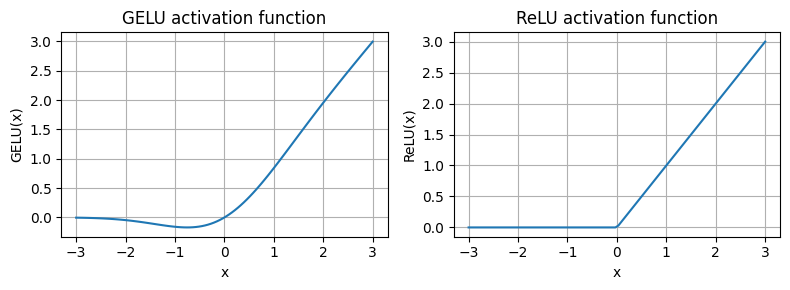

In [259]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (
            1 + torch.tanh(
                torch.sqrt(torch.tensor(2.0 / torch.pi))
                * (x + 0.044715 * torch.pow(x, 3))
            )
        )


# Create GELU and ReLU
gelu = GELU()
relu = nn.ReLU()

# Create input values
x = torch.linspace(-3, 3, 100)

# Calculate outputs
y_gelu = gelu(x)
y_relu = relu(x)


# Create figure
plt.figure(figsize=(8, 3))

# Plot GELU and ReLU
for i, (y, label) in enumerate(
    zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1
):
    plt.subplot(1, 2, i)

    plt.plot(x, y)

    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)

plt.tight_layout()
plt.show()

In [260]:
import torch
import torch.nn as nn
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)

In [261]:
ffn = FeedForward(GPT_CONFIG_124M)
x = torch.rand(2, 3, 768) #A
out = ffn(x)
print(out.shape)

torch.Size([2, 3, 768])


4.4 Adding shortcut connections


In [262]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            # Implement 5 layers
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU())
        ])

    def forward(self, x):
        for layer in self.layers:
            # Compute the output of the current layer
            layer_output = layer(x)
            # Check if shortcut can be applied
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output
        return x

In [263]:
def print_gradients(model, x):
    # Forward pass
    output = model(x)
    target = torch.tensor([[0.]])

    # Calculate loss based on how close the target
    # and output are
    loss = nn.MSELoss()
    loss = loss(output, target)

    # Backward pass to calculate the gradients
    loss.backward()

    for name, param in model.named_parameters():
        if 'weight' in name:
            # Print the mean absolute gradient of the weights
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

In [264]:
layer_sizes = [3, 3, 3, 3, 3, 1]
sample_input = torch.tensor([[1., 0., -1.]])
torch.manual_seed(123) # specify random seed for the initial weights for rep
model_without_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=False
)
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.00020173584925942123
layers.1.0.weight has gradient mean of 0.00012011159560643137
layers.2.0.weight has gradient mean of 0.0007152040489017963
layers.3.0.weight has gradient mean of 0.0013988736318424344
layers.4.0.weight has gradient mean of 0.005049645435065031


In [265]:
layer_sizes = [3, 3, 3, 3, 3, 1]
sample_input = torch.tensor([[1., 0., -1.]])
torch.manual_seed(123) # specify random seed for the initial weights for rep
model_without_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=True
)
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.22169791162014008
layers.1.0.weight has gradient mean of 0.20694105327129364
layers.2.0.weight has gradient mean of 0.32896995544433594
layers.3.0.weight has gradient mean of 0.2665732204914093
layers.4.0.weight has gradient mean of 1.3258540630340576


4.5 Connecting attention and linear layers in a transformer block

In [266]:
import torch
import torch.nn as nn

from previous_chapters import MultiHeadAttention


class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"]
        )

        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_resid = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Shortcut connection
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_resid(x)
        x = x + shortcut

        # Second shortcut connection
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_resid(x)
        x = x + shortcut

        return x

In [267]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 1024,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": False
}

In [268]:
import torch
import torch.nn as nn


# =========================================================
# 1. GELU activation
# =========================================================

class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (
            1 + torch.tanh(
                torch.sqrt(torch.tensor(2.0 / torch.pi))
                * (x + 0.044715 * torch.pow(x, 3))
            )
        )


# =========================================================
# 2. Multi-Head Attention
# =========================================================

class MultiHeadAttention(nn.Module):

    def __init__(
        self,
        d_in,
        d_out,
        context_length,
        dropout,
        num_heads,
        qkv_bias=False
    ):
        super().__init__()

        assert d_out % num_heads == 0, \
            "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        self.W_query = nn.Linear(
            d_in, d_out, bias=qkv_bias
        )

        self.W_key = nn.Linear(
            d_in, d_out, bias=qkv_bias
        )

        self.W_value = nn.Linear(
            d_in, d_out, bias=qkv_bias
        )

        self.out_proj = nn.Linear(
            d_out, d_out
        )

        self.dropout = nn.Dropout(dropout)

        # Causal mask
        self.register_buffer(
            "mask",
            torch.triu(
                torch.ones(
                    context_length,
                    context_length
                ),
                diagonal=1
            )
        )

    def forward(self, x):

        # x shape:
        # [batch_size, num_tokens, d_in]

        b, num_tokens, d_in = x.shape

        # Create keys, queries and values
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        # Split embedding dimension into multiple heads
        keys = keys.view(
            b,
            num_tokens,
            self.num_heads,
            self.head_dim
        )

        queries = queries.view(
            b,
            num_tokens,
            self.num_heads,
            self.head_dim
        )

        values = values.view(
            b,
            num_tokens,
            self.num_heads,
            self.head_dim
        )

        # Move num_heads before num_tokens
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Calculate attention scores
        attn_scores = queries @ keys.transpose(2, 3)

        # Apply causal mask
        mask_bool = self.mask.bool()[
            :num_tokens,
            :num_tokens
        ]

        attn_scores.masked_fill_(
            mask_bool,
            -torch.inf
        )

        # Convert scores to probabilities
        attn_weights = torch.softmax(
            attn_scores / (self.head_dim ** 0.5),
            dim=-1
        )

        attn_weights = self.dropout(
            attn_weights
        )

        # Calculate context vectors
        context_vec = attn_weights @ values

        # Put tokens before heads
        context_vec = context_vec.transpose(1, 2)

        # Combine heads
        context_vec = context_vec.contiguous().view(
            b,
            num_tokens,
            self.d_out
        )

        # Final linear projection
        context_vec = self.out_proj(
            context_vec
        )

        return context_vec


# =========================================================
# 3. Feed-Forward Network
# =========================================================

class FeedForward(nn.Module):

    def __init__(self, cfg):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Linear(
                cfg["emb_dim"],
                4 * cfg["emb_dim"]
            ),

            GELU(),

            nn.Linear(
                4 * cfg["emb_dim"],
                cfg["emb_dim"]
            )
        )

    def forward(self, x):
        return self.layers(x)


# =========================================================
# 4. Transformer Block
# =========================================================

class TransformerBlock(nn.Module):

    def __init__(self, cfg):
        super().__init__()

        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            dropout=cfg["drop_rate"],
            num_heads=cfg["n_heads"],
            qkv_bias=cfg["qkv_bias"]
        )

        self.ff = FeedForward(cfg)

        self.norm1 = nn.LayerNorm(
            cfg["emb_dim"]
        )

        self.norm2 = nn.LayerNorm(
            cfg["emb_dim"]
        )

        self.drop_shortcut = nn.Dropout(
            cfg["drop_rate"]
        )

    def forward(self, x):

        # Shortcut connection around attention
        shortcut = x

        x = self.norm1(x)

        x = self.att(x)

        x = self.drop_shortcut(x)

        x = x + shortcut


        # Shortcut connection around feed-forward network
        shortcut = x

        x = self.norm2(x)

        x = self.ff(x)

        x = self.drop_shortcut(x)

        x = x + shortcut

        return x


# =========================================================
# 5. GPT-2 124M Configuration
# =========================================================

GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 1024,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": False
}


# =========================================================
# 6. Test Transformer Block
# =========================================================

torch.manual_seed(123)

x = torch.rand(
    2,
    4,
    768
)

block = TransformerBlock(
    GPT_CONFIG_124M
)

output = block(x)


# =========================================================
# 7. Print shapes
# =========================================================

print("Input shape :", x.shape)
print("Output shape:", output.shape)

Input shape : torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])


In [269]:
import torch
torch.manual_seed(123)
x = torch.rand(2, 4, 768)  #A
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)

In [270]:
torch.manual_seed(123)

x = torch.rand(2, 4, 768)

block = TransformerBlock(GPT_CONFIG_124M)

output = block(x)

print("Input shape:", x.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])


In [271]:
x.shape

torch.Size([2, 4, 768])

In [272]:
output.shape

torch.Size([2, 4, 768])

4.6 Coding the GPT model

In [273]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"
batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)


tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [274]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]) #
        self.final_norm = LayerNorm(cfg["emb_dim"]) #B
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [275]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
out = model(batch)

In [276]:
print("Token embedding layer shape:", model.tok_emb.weight.shape)

Token embedding layer shape: torch.Size([50257, 768])


In [277]:
print("Output layer shape:", model.out_head.weight.shape)

Output layer shape: torch.Size([50257, 768])


In [278]:
batch.shape

torch.Size([2, 4])

In [279]:
out.shape

torch.Size([2, 4, 50257])

In [280]:
batch.numel()

8

In [281]:
total_params = sum(p.numel() for p in model.parameters())
total_params

163009536

In [282]:
def generate_text_simple(model, idx, max_new_tokens, context_size): #A
       for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:] #B
        with torch.no_grad():
            logits = model(idx_cond)

        logits = logits[:, -1, :] #C
        probas = torch.softmax(logits, dim=-1)  #D
        idx_next = torch.argmax(probas, dim=-1, keepdim=True) #E
        idx = torch.cat((idx, idx_next), dim=1)  #F

        return idx

In [283]:
torch.argmax(torch.tensor([14,1,-2,1,15] ))

tensor(4)

In [284]:
start_context = "Hello, I am"
encoded = tokenizer.encode(start_context)
print("encoded:", encoded)

encoded: [15496, 11, 314, 716]


In [285]:
encoded_tensor = torch.tensor(encoded).unsqueeze(0) #A
print("encoded_tensor.shape:", encoded_tensor.shape)

encoded_tensor.shape: torch.Size([1, 4])


In [286]:
start_context = "Hello, I am"
encoded = tokenizer.encode(start_context)
print("encoded:", encoded)

encoded: [15496, 11, 314, 716]


In [287]:
encoded_tensor = torch.tensor(encoded).unsqueeze(0) #A
print("encoded_tensor.shape:", encoded_tensor.shape)

encoded_tensor.shape: torch.Size([1, 4])


In [288]:
encoded_tensor

tensor([[15496,    11,   314,   716]])

In [289]:
out = generate_text_simple(
model=model,
idx=encoded_tensor,
max_new_tokens=6,
context_size=GPT_CONFIG_124M["context_length"]
)

In [290]:
out

tensor([[15496,    11,   314,   716, 27018]])

In [291]:
out.squeeze(0).tolist()

[15496, 11, 314, 716, 27018]

In [292]:
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

Hello, I am Feature


5 Pretraining on Unlabeled Data
5.1 Evaluating generative text models

In [293]:
GPT_CONFIG_124M = {
"vocab_size": 50257,
"context_length": 256,  #A
"emb_dim": 768,
"n_heads": 12,
"n_layers": 12,
"drop_rate": 0.1,
#B
"qkv_bias": False
}

In [294]:
import torch

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): Tran

In [295]:
def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(
        text,
        allowed_special={'<|endoftext|>'}
    )

    encoded_tensor = torch.tensor(encoded).unsqueeze(0)

    return encoded_tensor

In [296]:
start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")
text_to_token_ids(start_context, tokenizer)

tensor([[6109, 3626, 6100,  345]])

In [297]:
def token_ids_to_text(token_ids, tokenizer):
                                   flat = token_ids.squeeze(0) # remove batch dimension
                                   return tokenizer.decode(flat.tolist())
start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")
token_ids = generate_text_simple(
model=model,
idx=text_to_token_ids(start_context, tokenizer),
max_new_tokens=10,
context_size=GPT_CONFIG_124M["context_length"]
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you renting


In [298]:
token_ids.squeeze(0).shape


torch.Size([5])

5.1.2 Calculating the text generation loss

In [299]:
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
[40,
1107, 588]])   #  "I really like"]
targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
[588,  428,  11311]]) #  " really like choc

In [300]:
with torch.no_grad(): #A
           logits = model(inputs)

In [301]:
logits.shape

torch.Size([2, 3, 50257])

In [302]:
probas = torch.softmax(logits, dim=-1) # Probability of each token in vocabu
print(probas.shape)

torch.Size([2, 3, 50257])


In [303]:
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print("Token IDs:\n", token_ids)

Token IDs:
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


In [304]:
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print("Token IDs:\n", token_ids)

Token IDs:
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


In [305]:
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1: {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Targets batch 1:  effort moves you
Outputs batch 1:  Armed heNetflix


In [306]:
text_idx = 0
target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 1:", target_probas_1)

Text 1: tensor([0.0001, 0.0000, 0.0000])


In [307]:
text_idx = 1
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 2:", target_probas_2)

Text 2: tensor([0.0000, 0.0000, 0.0000])


In [308]:
torch.set_printoptions(precision=10)

print(probas)

tensor([[[1.8849092157e-05, 1.5172131498e-05, 1.1687467122e-05,
           ..., 2.2408949008e-05, 6.9776110649e-06,
          1.8775850549e-05],
         [9.1569027063e-06, 1.0061819012e-05, 7.8785897131e-06,
           ..., 2.9089749660e-05, 6.0102915995e-06,
          1.3570737792e-05],
         [2.9876950066e-05, 8.8507113105e-06, 1.5741004972e-05,
           ..., 3.5455621401e-05, 1.4094410290e-05,
          1.3526037947e-05]],

        [[1.2560989489e-05, 2.0537529053e-05, 1.4332283172e-05,
           ..., 1.0388653209e-05, 3.4783977753e-05,
          1.4238841686e-05],
         [7.2730936154e-06, 1.7864371330e-05, 1.0564530385e-05,
           ..., 2.1206475139e-05, 1.1389538486e-05,
          1.5559186068e-05],
         [2.9496361094e-05, 3.3605359931e-05, 4.1029321437e-05,
           ..., 6.5249323598e-06, 5.8202687796e-05,
          1.3697900613e-05]]])


In [309]:
targets[text_idx]

tensor([  588,   428, 11311])

In [310]:
torch.log((torch.cat((target_probas_1, target_probas_2))))

tensor([ -9.5041675568, -10.3795719147, -11.3677186966, -10.1307497025,
        -10.9951343536, -12.2561187744])

In [311]:
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
print(log_probas)

tensor([ -9.5041675568, -10.3795719147, -11.3677186966, -10.1307497025,
        -10.9951343536, -12.2561187744])


In [312]:
-1*torch.mean(log_probas)

tensor(10.7722434998)

In [313]:
logits.shape

torch.Size([2, 3, 50257])

In [314]:
logits_flat = logits.flatten(0, 1)
logits_flat.shape

torch.Size([6, 50257])

In [315]:
targets_flat = targets.flatten()
targets_flat.shape

torch.Size([6])

In [316]:
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(loss)

tensor(10.7722434998)


5.1.3

In [317]:
import os
import urllib.request

file_path = "the-verdict.txt"

url = "https://raw.githubusercontent.com/celdeev/git-course/main/the-verdict.txt"

if not os.path.exists(file_path):

    with urllib.request.urlopen(url) as response:
        text_data = response.read().decode("utf-8")

    with open(file_path, "w", encoding="utf-8") as file:
        file.write(text_data)

else:

    with open(file_path, "r", encoding="utf-8") as file:
        text_data = file.read()

print("File loaded successfully!")
print("Number of characters:", len(text_data))

File loaded successfully!
Number of characters: 20479


In [318]:
text_data[:99]

'I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no '

In [319]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 20479
Tokens: 5145


In [320]:
int(0.9*len(text_data))

18431

In [321]:
text_data[18431:]

'ue\' collapsed like a house of cards. He didn\'t sneer, you understand, poor Stroud--he just lay there quietly watching, and on his lips, through the gray beard, I seemed to hear the question: \'Are you sure you know where you\'re coming out?\'\n\n"If I could have painted that face, with that question on it, I should have done a great thing. The next greatest thing was to see that I couldn\'t--and that grace was given me. But, oh, at that minute, Rickham, was there anything on earth I wouldn\'t have given to have Stroud alive before me, and to hear him say: \'It\'s not too late--I\'ll show you how\'?\n\n"It _was_ too late--it would have been, even if he\'d been alive. I packed up my traps, and went down and told Mrs. Stroud. Of course I didn\'t tell her _that_--it would have been Greek to her. I simply said I couldn\'t paint him, that I was too moved. She rather liked the idea--she\'s so romantic! It was that that made her give me the donkey. But she was terribly upset at not getting 

In [322]:
from previous_chapters import create_dataloader_v1
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

In [323]:
train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True
)
val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False
)

In [324]:
print("Train loader:")
for x, y in train_loader:
  print(x.shape, y.shape)
print("\nValidation loader:")
for x, y in val_loader:
  print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


In [325]:
x.numel()

512

In [326]:
train_tokens=0
for input_batch,target_batch in train_loader:
  train_tokens += input_batch.numel()
  val_tokens=0
  for input_batch,target_batch in val_loader:
    val_tokens +=input_batch.numel()
    print("train tokens:", train_tokens)
    print("validation tokens:", val_tokens)
    print("All tokens:", train_tokens+val_tokens)



train tokens: 512
validation tokens: 512
All tokens: 1024
train tokens: 1024
validation tokens: 512
All tokens: 1536
train tokens: 1536
validation tokens: 512
All tokens: 2048
train tokens: 2048
validation tokens: 512
All tokens: 2560
train tokens: 2560
validation tokens: 512
All tokens: 3072
train tokens: 3072
validation tokens: 512
All tokens: 3584
train tokens: 3584
validation tokens: 512
All tokens: 4096
train tokens: 4096
validation tokens: 512
All tokens: 4608
train tokens: 4608
validation tokens: 512
All tokens: 5120


In [327]:
def calc_loss_batch(input_batch, target_batch, model, device):

    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)

    logits = model(input_batch)

    loss = torch.nn.functional.cross_entropy(
        logits.flatten(0, 1),
        target_batch.flatten()
    )

    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if num_batches is None:
        num_batches = len(data_loader) #A
    else:
        num_batches = min(num_batches, len(data_loader)) #B
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item() #C
        else:
            break
    return total_loss / num_batches #D


In [328]:
def calc_loss_batch(input_batch, target_batch, model, device):

    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)

    logits = model(input_batch)

    loss = torch.nn.functional.cross_entropy(
        logits.flatten(0, 1),
        target_batch.flatten()
    )

    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):

    total_loss = 0.0

    if num_batches is None:
        num_batches = len(data_loader)  # A
    else:
        num_batches = min(num_batches, len(data_loader))  # B

    for i, (input_batch, target_batch) in enumerate(data_loader):

        if i < num_batches:
            loss = calc_loss_batch(
                input_batch,
                target_batch,
                model,
                device
            )

            total_loss += loss.item()  # C

        else:
            break

    return total_loss / num_batches  # D

In [329]:
torch.cuda.is_available()

False

In [330]:
torch.mps.is_available()

False

In [331]:
torch.cpu.is_available()

True

In [332]:
torch.device("mps")

device(type='mps')

In [333]:
print(input_batch.device)

cpu


In [334]:
print(next(model.parameters()).device)

cpu


In [335]:
torch.manual_seed(123)
with torch.no_grad():
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu") #A
model.to(device)
train_loss = calc_loss_loader(train_loader, model, device)
val_loss = calc_loss_loader(val_loader, model, device)
print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 10.98758347829183
Validation loss: 10.98110580444336


In [336]:
#preplexity
torch.exp(torch.tensor(0.5))

tensor(1.6487212181)

In [337]:
tokenizer.n_vocab

50257

5.2 Training an LLM


In [338]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context,tokenizer):
    train_losses, val_losses, track_tokens_seen = [], [], [] #A
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs): #B
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() #C
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() #D
            optimizer.step() #E
            tokens_seen += input_batch.numel()
            global_step += 1

            if global_step % eval_freq == 0: #F
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}: "
                f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        generate_and_print_sample(
            model, train_loader.dataset.tokenizer, device, start_context
        )
    return train_losses, val_losses, track_tokens_seen


In [339]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval() #A
    with torch.no_grad(): #B
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

In [340]:
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
        decoded_text = token_ids_to_text(token_ids, tokenizer)
        print(decoded_text.replace("\n", " "))  # Compact print format
    model.train()

In [341]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)


In [342]:
num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
model, train_loader, val_loader, optimizer, device,
num_epochs=num_epochs, eval_freq=5, eval_iter=1,
start_context="Every effort moves you",tokenizer=tokenizer
)

Ep 1 (Step 000000: Train loss 9.897, Val loss 9.933
Ep 1 (Step 000005: Train loss 7.917, Val loss 8.339
Every effort moves you,
Ep 2 (Step 000010: Train loss 6.847, Val loss 7.048
Ep 2 (Step 000015: Train loss 5.997, Val loss 6.616
Every effort moves you,
Ep 3 (Step 000020: Train loss 5.659, Val loss 6.600
Ep 3 (Step 000025: Train loss 5.363, Val loss 6.348
Every effort moves you,
Ep 4 (Step 000030: Train loss 4.010, Val loss 6.278
Ep 4 (Step 000035: Train loss 2.549, Val loss 6.226
Every effort moves you know
Ep 5 (Step 000040: Train loss 3.834, Val loss 6.160
Every effort moves you know
Ep 6 (Step 000045: Train loss 2.516, Val loss 6.179
Ep 6 (Step 000050: Train loss 3.006, Val loss 6.141
Every effort moves you know
Ep 7 (Step 000055: Train loss 2.575, Val loss 6.134
Ep 7 (Step 000060: Train loss 1.757, Val loss 6.233
Every effort moves you know
Ep 8 (Step 000065: Train loss 0.958, Val loss 6.238
Ep 8 (Step 000070: Train loss 1.497, Val loss 6.242
Every effort moves you know
Ep 9 (St

In [343]:
import matplotlib.pyplot as plt


def plot_losses(train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    ax1.plot(train_losses, label="Training loss")
    ax1.plot(val_losses, label="Validation loss")

    ax1.set_xlabel("Evaluation step")
    ax1.set_ylabel("Loss")
    ax1.legend()

    plt.tight_layout()
    plt.show()

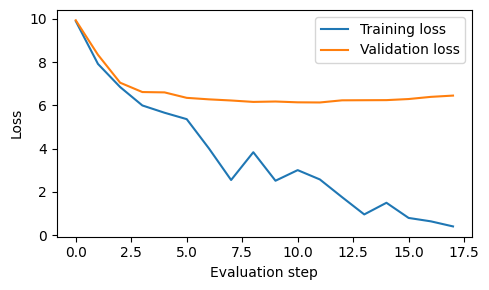

In [344]:
plot_losses(train_losses, val_losses)

In [345]:
def train_model_simple(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    num_epochs,
    eval_freq,
    eval_iter,
    start_context,
    tokenizer
):
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs):

        model.train()

        for input_batch, target_batch in train_loader:

            optimizer.zero_grad()

            loss = calc_loss_batch(
                input_batch,
                target_batch,
                model,
                device
            )

            loss.backward()
            optimizer.step()

            tokens_seen += input_batch.numel()
            global_step += 1

            if global_step % eval_freq == 0:

                train_loss, val_loss = evaluate_model(
                    model,
                    train_loader,
                    val_loader,
                    device,
                    eval_iter
                )

                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)

                print(
                    f"Ep {epoch + 1} "
                    f"(Step {global_step:06d}): "
                    f"Train loss {train_loss:.3f}, "
                    f"Val loss {val_loss:.3f}"
                )

        generate_and_print_sample(
            model,
            tokenizer,
            device,
            start_context
        )

    return train_losses, val_losses, track_tokens_seen

In [346]:
def evaluate_model(
    model,
    train_loader,
    val_loader,
    device,
    eval_iter
):
    model.eval()

    with torch.no_grad():

        train_loss = calc_loss_loader(
            train_loader,
            model,
            device,
            num_batches=eval_iter
        )

        val_loss = calc_loss_loader(
            val_loader,
            model,
            device,
            num_batches=eval_iter
        )

    model.train()

    return train_loss, val_loss

In [347]:
def generate_and_print_sample(
    model,
    tokenizer,
    device,
    start_context
):
    model.eval()

    context_size = model.pos_emb.weight.shape[0]

    encoded = text_to_token_ids(
        start_context,
        tokenizer
    ).to(device)

    with torch.no_grad():

        token_ids = generate_text_simple(
            model=model,
            idx=encoded,
            max_new_tokens=50,
            context_size=context_size
        )

        decoded_text = token_ids_to_text(
            token_ids,
            tokenizer
        )

        print(decoded_text.replace("\n", " "))

    model.train()

In [348]:
torch.manual_seed(123)

model = GPTModel(GPT_CONFIG_124M)
model.to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0004,
    weight_decay=0.1
)

num_epochs = 10

train_losses, val_losses, tokens_seen = train_model_simple(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    num_epochs=num_epochs,
    eval_freq=5,
    eval_iter=1,
    start_context="Every effort moves you",
    tokenizer=tokenizer
)

Ep 1 (Step 000000): Train loss 9.897, Val loss 9.933
Ep 1 (Step 000005): Train loss 7.917, Val loss 8.339
Every effort moves you,
Ep 2 (Step 000010): Train loss 6.847, Val loss 7.048
Ep 2 (Step 000015): Train loss 5.997, Val loss 6.616
Every effort moves you,
Ep 3 (Step 000020): Train loss 5.659, Val loss 6.600
Ep 3 (Step 000025): Train loss 5.363, Val loss 6.348
Every effort moves you,
Ep 4 (Step 000030): Train loss 4.010, Val loss 6.278
Ep 4 (Step 000035): Train loss 2.549, Val loss 6.226
Every effort moves you know
Ep 5 (Step 000040): Train loss 3.834, Val loss 6.160
Every effort moves you know
Ep 6 (Step 000045): Train loss 2.516, Val loss 6.179
Ep 6 (Step 000050): Train loss 3.006, Val loss 6.141
Every effort moves you know
Ep 7 (Step 000055): Train loss 2.575, Val loss 6.134
Ep 7 (Step 000060): Train loss 1.757, Val loss 6.233
Every effort moves you know
Ep 8 (Step 000065): Train loss 0.958, Val loss 6.238
Ep 8 (Step 000070): Train loss 1.497, Val loss 6.242
Every effort moves yo

5.3 Decoding strategies to control randomness

In [349]:
model.to("cpu")
model.eval()
tokenizer = tiktoken.get_encoding("gpt2")
token_ids = generate_text_simple(
model=model,
idx=text_to_token_ids("Every effort moves you", tokenizer),
max_new_tokens=25,
context_size=GPT_CONFIG_124M["context_length"]
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you know


In [350]:
vocab = {
"closer": 0,
"every": 1,
"effort": 2,
"forward": 3,
"inches": 4,
"moves": 5,
"pizza": 6,
"toward": 7,
"you": 8,
}
inverse_vocab = {v: k for k, v in vocab.items()}
inverse_vocab

{0: 'closer',
 1: 'every',
 2: 'effort',
 3: 'forward',
 4: 'inches',
 5: 'moves',
 6: 'pizza',
 7: 'toward',
 8: 'you'}

In [351]:
next_token_logits = torch.tensor(
[4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)
probas = torch.softmax(next_token_logits, dim=0)
probas

tensor([6.0907062143e-02, 1.6312533990e-03, 1.0019362526e-04, 5.7212007046e-01,
        3.4190029837e-03, 1.3256912644e-04, 1.0120050865e-04, 3.5757640004e-01,
        4.0122363716e-03])

In [352]:
next_token_id = torch.argmax(probas).item()
next_token_id

3

In [353]:
torch.manual_seed(123)
next_token_id = torch.multinomial(probas, num_samples=1).item()
print(inverse_vocab[next_token_id])

forward


In [354]:
def print_sampled_tokens(probas):
            torch.manual_seed(123)
sample = [torch.multinomial(probas, num_samples=1).item() for i in range(1_000)]
sampled_ids = torch.bincount(torch.tensor(sample))
for i, freq in enumerate(sampled_ids):
       print(f"{freq} x {inverse_vocab[i]}")
print_sampled_tokens(probas)

73 x closer
0 x every
0 x effort
581 x forward
2 x inches
0 x moves
0 x pizza
344 x toward


In [355]:
def softmax_with_temperature(logits, temperature):
         scaled_logits = logits / temperature
         return torch.softmax(scaled_logits, dim=0)

In [356]:
temperatures = [1, 0.1, 5]

scaled_probas = [
    softmax_with_temperature(next_token_logits, T)
    for T in temperatures
]

In [357]:
scaled_probas[0]

tensor([6.0907062143e-02, 1.6312533990e-03, 1.0019362526e-04, 5.7212007046e-01,
        3.4190029837e-03, 1.3256912644e-04, 1.0120050865e-04, 3.5757640004e-01,
        4.0122363716e-03])

In [358]:
scaled_probas[1]

tensor([1.8529870693e-10, 3.5189399408e-26, 2.6890267328e-38, 9.9098664522e-01,
        5.7569175597e-23, 4.4220230814e-37, 2.9718297824e-38, 9.0133249760e-03,
        2.8514262206e-22])

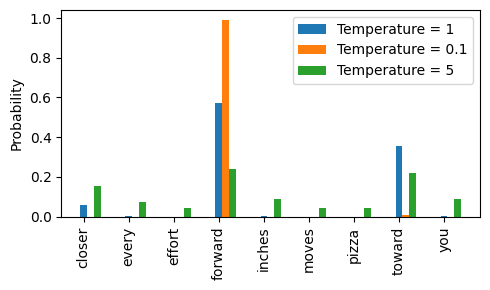

In [359]:

x = torch.arange(len(vocab))
bar_width = 0.15
fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i],
bar_width, label=f'Temperature = {T}')
ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

In [360]:
next_token_logits = torch.tensor(
[4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

In [361]:
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)
print("Top logits:", top_logits)
print("Top positions:", top_pos)

Top logits: tensor([6.7500000000, 6.2800002098, 4.5100002289])
Top positions: tensor([3, 7, 0])


In [362]:
next_token_logits < top_logits[-1]

tensor([False,  True,  True, False,  True,  True,  True, False,  True])

In [363]:
new_logits = torch.where(
condition=next_token_logits < top_logits[-1],  #A
input=torch.tensor(float('-inf')),  #B
other=next_token_logits  #C
)
print(new_logits)

tensor([4.5100002289,         -inf,         -inf, 6.7500000000,         -inf,
                -inf,         -inf, 6.2800002098,         -inf])


In [364]:
topk_probas = torch.softmax(new_logits, dim=0)
print(topk_probas)

tensor([0.0614847988, 0.0000000000, 0.0000000000, 0.5775469542, 0.0000000000,
        0.0000000000, 0.0000000000, 0.3609682322, 0.0000000000])


5.3.3 Modifying the text generation function


In [365]:
def generate(
    model,
    idx,
    max_new_tokens,
    context_size,
    temperature=0.0,
    top_k=None,
    eos_id=None
):
    for _ in range(max_new_tokens):

        # Keep only the most recent tokens
        idx_cond = idx[:, -context_size:]

        # Generate logits
        with torch.no_grad():
            logits = model(idx_cond)

        # Keep logits for the last token
        logits = logits[:, -1, :]

        # Top-k sampling
        if top_k is not None:
            top_logits, _ = torch.topk(logits, top_k)

            min_top_logits = top_logits[:, -1]

            logits = torch.where(
                logits < min_top_logits,
                torch.tensor(float("-inf")).to(logits.device),
                logits
            )

        # Temperature sampling
        if temperature > 0.0:
            logits = logits / temperature
            probs = torch.softmax(logits, dim=-1)

            idx_next = torch.multinomial(
                probs,
                num_samples=1
            )

        # Greedy sampling
        else:
            idx_next = torch.argmax(
                logits,
                dim=-1,
                keepdim=True
            )

        # Stop when EOS token is generated
        if eos_id is not None and idx_next.item() == eos_id:
            break

        # Add new token to sequence
        idx = torch.cat(
            (idx, idx_next),
            dim=1
        )

    return idx

In [366]:
torch.manual_seed(123)
token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you stand to work on surprise, a one of us had gone with random-


5.4 Loading and saving model weights in PyTorch


In [367]:
model.state_dict()

OrderedDict([('tok_emb.weight',
              tensor([[ 3.4378048778e-01, -1.7098461092e-01, -3.0867677927e-01,
                        ..., -3.1839919090e-01, -1.3841896057e+00,
                        5.2873986959e-01],
                      [ 2.6058927178e-01,  3.4740447998e-01, -8.2215839624e-01,
                        ..., -4.0670442581e-01,  4.9834927917e-01,
                       -3.7239217758e-01],
                      [ 7.9287976027e-01,  5.3308737278e-01,  9.3936145306e-01,
                        ..., -1.0710097551e+00,  9.5148645341e-02,
                       -1.4087188244e+00],
                      ...,
                      [-7.1022033691e-01, -5.0009876490e-01,  1.4068115950e+00,
                        ..., -1.4924912155e-01, -4.8801383376e-01,
                       -1.0581865311e+00],
                      [ 2.0571534634e+00,  1.1149541140e+00,  3.8347783685e-01,
                        ..., -7.1756625175e-01, -5.5502611399e-01,
                        9.82849597

In [368]:
torch.save(model.state_dict(), "model.pth")

In [369]:
from previous_chapters import GPTModel
GPT_CONFIG_124M = {
"vocab_size": 50257,
"context_length": 256,  #A
"emb_dim": 768,
"n_heads": 12,
"n_layers": 12,
"drop_rate": 0.1,
#B
"qkv_bias": False
}
model = GPTModel(GPT_CONFIG_124M)

In [370]:
torch.load("model.pth", map_location=device)

OrderedDict([('tok_emb.weight',
              tensor([[ 3.4378048778e-01, -1.7098461092e-01, -3.0867677927e-01,
                        ..., -3.1839919090e-01, -1.3841896057e+00,
                        5.2873986959e-01],
                      [ 2.6058927178e-01,  3.4740447998e-01, -8.2215839624e-01,
                        ..., -4.0670442581e-01,  4.9834927917e-01,
                       -3.7239217758e-01],
                      [ 7.9287976027e-01,  5.3308737278e-01,  9.3936145306e-01,
                        ..., -1.0710097551e+00,  9.5148645341e-02,
                       -1.4087188244e+00],
                      ...,
                      [-7.1022033691e-01, -5.0009876490e-01,  1.4068115950e+00,
                        ..., -1.4924912155e-01, -4.8801383376e-01,
                       -1.0581865311e+00],
                      [ 2.0571534634e+00,  1.1149541140e+00,  3.8347783685e-01,
                        ..., -7.1756625175e-01, -5.5502611399e-01,
                        9.82849597

In [372]:
print("Tensorflow version:", version("Tensorflow"))
print("tqdm version:", version("tqdm"))


NameError: name 'version' is not defined

In [373]:
from importlib.metadata import version

print("TensorFlow version:", version("tensorflow"))
print("tqdm version:", version("tqdm"))

TensorFlow version: 2.20.0
tqdm version: 4.67.3


In [374]:
from gpt_download import download_and_load_gpt2

In [375]:
settings, params = download_and_load_gpt2(model_size="124M", models_dir="gpt2")

checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 138kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:00<00:00, 3.20MiB/s]
hparams.json: 100%|██████████| 90.0/90.0 [00:00<00:00, 120kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 498M/498M [00:49<00:00, 10.1MiB/s]
model.ckpt.index: 100%|██████████| 5.21k/5.21k [00:00<00:00, 6.64MiB/s]
model.ckpt.meta: 100%|██████████| 471k/471k [00:00<00:00, 1.90MiB/s]
vocab.bpe: 100%|██████████| 456k/456k [00:00<00:00, 1.88MiB/s]


In [376]:
print("Settings:", settings)

Settings: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}


In [377]:
print("Parameter dictionary keys:", params.keys())

Parameter dictionary keys: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


In [379]:
print(params["wte"])
print("Token embedding weight tensor dimensions:", params["wte"].shape)

[[-0.11010301 -0.03926672  0.03310751 ... -0.1363697   0.01506208
   0.04531523]
 [ 0.04034033 -0.04861503  0.04624869 ...  0.08605453  0.00253983
   0.04318958]
 [-0.12746179  0.04793796  0.18410145 ...  0.08991534 -0.12972379
  -0.08785918]
 ...
 [-0.04453601 -0.05483596  0.01225674 ...  0.10435229  0.09783269
  -0.06952604]
 [ 0.1860082   0.01665728  0.04611587 ... -0.09625227  0.07847701
  -0.02245961]
 [ 0.05135201 -0.02768905  0.0499369  ...  0.00704835  0.15519823
   0.12067825]]
Token embedding weight tensor dimensions: (50257, 768)
